In [15]:
import probeinterface as pi
import json
import split as sp

folder = "/groups/voigts/voigtslab/neuropixels_2025/npx07/2025_06_17_npx07_day2/"
data_folder = folder + "data"
probe_file = folder + "probe_conf.json"



def load_probe(probe_name):
    probe_file = folder + f"npx07_{probe_name}_probe_conf.json"
    # Load probe configuration file
    with open(probe_file, 'r') as f:
        probe_dict = json.load(f)
    
    print(probe_dict['probes'][0].keys())

    # Create probe from dictionary
    probe = pi.Probe.from_dict(probe_dict['probes'][0])
    probe.set_shank_ids(probe_dict['probes'][0]["shank_ids"])
    probe.set_contact_ids(probe_dict['probes'][0]["contact_ids"])
    probe_dict[probe_name] = {'probe': probe, 'shankInd': probe_file}
    return probe_dict

probe_A = load_probe('a')
probe_B = load_probe('b')


dict_keys(['ndim', 'si_units', 'annotations', 'contact_positions', 'contact_plane_axes', 'contact_shapes', 'contact_shape_params', 'probe_planar_contour', 'device_channel_indices', 'contact_ids', 'shank_ids'])
dict_keys(['ndim', 'si_units', 'annotations', 'contact_positions', 'contact_plane_axes', 'contact_shapes', 'contact_shape_params', 'probe_planar_contour', 'device_channel_indices', 'contact_ids', 'shank_ids'])


In [9]:
probe_data = {
    'np2-a' : probe_A,
    'np2-b' : probe_B
}

probe_data

{'np2-a': {'specification': 'probeinterface',
  'version': '0.2.21',
  'probes': [{'ndim': 2,
    'si_units': 'um',
    'annotations': {'name': 'Neuropixels 2.0 - Multishank',
     'manufacturer': 'IMEC'},
    'contact_positions': [[219.0, 170.0],
     [251.0, 170.0],
     [219.0, 185.0],
     [251.0, 185.0],
     [219.0, 200.0],
     [251.0, 200.0],
     [219.0, 215.0],
     [251.0, 215.0],
     [219.0, 230.0],
     [251.0, 230.0],
     [219.0, 245.0],
     [251.0, 245.0],
     [219.0, 260.0],
     [251.0, 260.0],
     [219.0, 275.0],
     [251.0, 275.0],
     [219.0, 290.0],
     [251.0, 290.0],
     [219.0, 305.0],
     [251.0, 305.0],
     [219.0, 320.0],
     [251.0, 320.0],
     [219.0, 335.0],
     [251.0, 335.0],
     [219.0, 350.0],
     [251.0, 350.0],
     [219.0, 365.0],
     [251.0, 365.0],
     [219.0, 380.0],
     [251.0, 380.0],
     [219.0, 395.0],
     [251.0, 395.0],
     [219.0, 410.0],
     [251.0, 410.0],
     [219.0, 425.0],
     [251.0, 425.0],
     [219.0, 440.

In [13]:
plot_probe?

Signature:
plot_probe(
    probe,
    ax=None,
    contacts_colors=None,
    with_contact_id: 'bool' = False,
    with_device_index: 'bool' = False,
    text_on_contact: 'list | np.ndarray | None' = None,
    contacts_values: 'np.ndarray | None' = None,
    cmap: 'str' = 'viridis',
    title: 'bool' = True,
    contacts_kargs: 'dict' = {},
    probe_shape_kwargs: 'dict' = {},
    xlims: 'tuple | None' = None,
    ylims: 'tuple | None' = None,
    zlims: 'tuple | None' = None,
    show_channel_on_click: 'bool' = False,
)
Docstring:
Plot a Probe object.
Generates a 2D or 3D axis, depending on Probe.ndim

Parameters
----------
probe : Probe
    The probe object
ax : matplotlib.axis | None, default: None
    The axis to plot the probe on. If None, an axis is created
contacts_colors : matplotlib color | None, default: None
    The color of the contacts
with_contact_id : bool, default: False
    If True, channel ids are displayed on top of the channels
with_device_index : bool, default: Fals

(<matplotlib.collections.PolyCollection at 0x7d73f87c0bb0>,
 <matplotlib.collections.PolyCollection at 0x7d73f83563a0>)

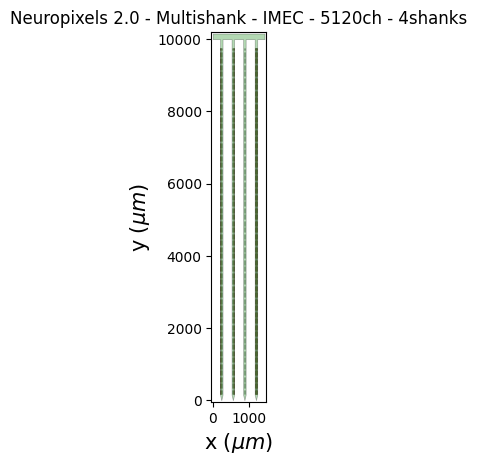

In [12]:
from probeinterface.plotting import plot_probe
plot_probe(probe_B['b']['probe'])

In [4]:
probe_names = ['np2-b', 'np2-a']
recording_files = sp.collect_files(data_folder, probe_names, output_folder=False)

np2-b
Found 14 files for np2-b
np2-a
Found 14 files for np2-a


In [5]:
shank_dict, recording_paths = sp.split_recording(recording_files, probe_names, probe_data)

15446.244
3450.607
414.659
3412.638
73.287
183.065
8825.79
160.89836666666667
35.9438
4.319333333333334
35.5483
0.7634
1.9069
91.9353


AssertionError: Values must have the same size as the main ids: 384 but got array of size 4

In [24]:
# Get shank information from probe_A
shank_info = probe_A.get_shanks()
print(f"Number of shanks: {len(shank_info)}")
print("\nShank details:")
for i, shank in enumerate(shank_info):
    print(f"Shank {i}:")
    print(f"  Number of channels: {len(shank)}")
    print(f"  Channel indices: {shank}")

Number of shanks: 4

Shank details:
Shank 0:


TypeError: object of type 'Shank' has no len()

In [26]:
probe_A.get_shanks()[2]